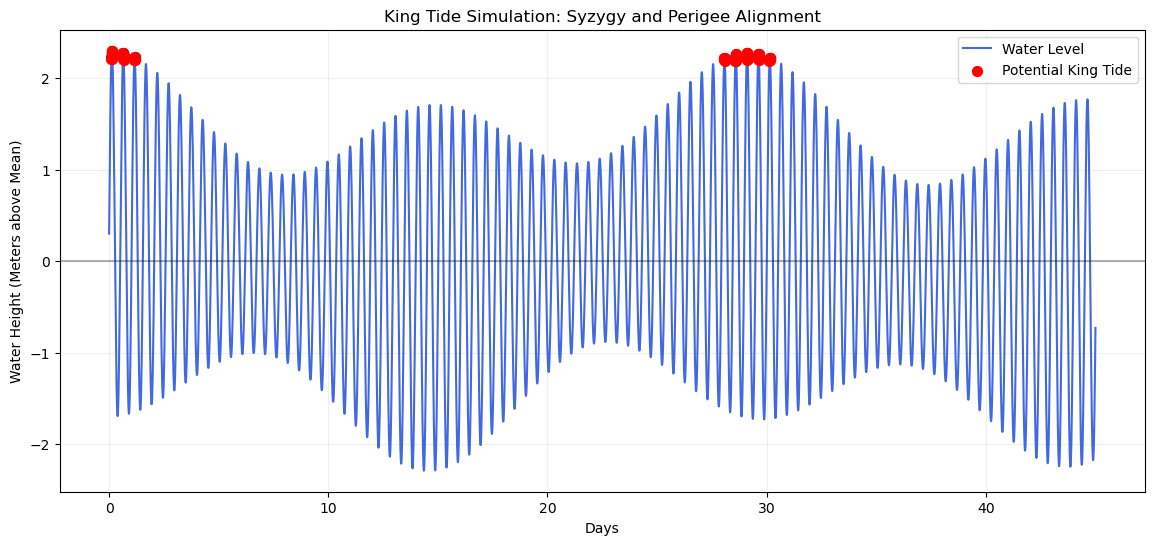

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_tides(days=31):
    hours = np.linspace(0, days * 24, days * 24 * 10)
    
    # 1. Standard Daily Tide (approx 12.4 hour cycle)
    # Magnitude: 1.0 meter
    daily_tide = 1.0 * np.sin(2 * np.pi * hours / 12.42)
    
    # 2. Spring/Neap Cycle (approx 14.7 days between Spring tides)
    # This acts as an envelope that grows and shrinks the daily tide
    spring_cycle = 0.5 * np.cos(2 * np.pi * hours / (14.7 * 24)) + 0.5
    
    # 3. Perigean Influence (Moon's distance - 27.5 day cycle)
    # Adds an extra boost when the moon is at perigee
    perigee_boost = 0.3 * np.cos(2 * np.pi * hours / (27.55 * 24))
    
    # Total Water Level
    # We multiply the daily tide by the spring cycle (modulation) 
    # and add the perigee boost (base shift)
    water_level = (daily_tide * (1 + spring_cycle)) + perigee_boost
    
    return hours / 24, water_level

# Generate Data
days_axis, tide_height = simulate_tides(45) # Simulate 45 days to see alignment

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(days_axis, tide_height, color='royalblue', label='Water Level')

# Identify King Tide (Threshold: highest peaks in the simulation)
peak_threshold = np.max(tide_height) * 0.95
king_tide_indices = np.where(tide_height > peak_threshold)[0]
plt.scatter(days_axis[king_tide_indices], tide_height[king_tide_indices], 
            color='red', s=50, label='Potential King Tide', zorder=5)

plt.axhline(0, color='black', alpha=0.3)
plt.title("King Tide Simulation: Syzygy and Perigee Alignment")
plt.xlabel("Days")
plt.ylabel("Water Height (Meters above Mean)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()